# Spectral Visualization from Excel Data

This notebook converts spectral emission/absorption data into a visual representation.

## How to use:
1. Place an Excel file (.xlsx) in this folder with columns:
   - **Column A**: Spectrum type (e.g., element name)
   - **Column B**: Observed wavelength in nm
   - **Column C**: Relative intensity (or counts)
2. Run the cells in order to:
   - Load dependencies
   - Read the Excel file
   - Generate and display the spectral image

## Output:
A horizontal bar showing the spectrum across the visible range (≈400–700 nm), 
with colors and brightness corresponding to wavelengths and intensities. 
Black regions indicate no emission data at those wavelengths.

In [ ]:
import sys
import subprocess

def ensure_package(package_name):
    try:
        __import__(package_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

ensure_package("numpy")
ensure_package("matplotlib")

import numpy as np
import matplotlib.pyplot as plt

## Load Excel File

In [44]:
# Load spectral data from Excel file
import openpyxl
import os
from collections import Counter

# Find the newest non-temporary Excel file in the workspace
xlsx_files = [
    f for f in os.listdir('.')
    if f.lower().endswith('.xlsx') and not f.startswith('~$')
]
if not xlsx_files:
    raise FileNotFoundError('No Excel file found in workspace')

excel_file = max(xlsx_files, key=os.path.getmtime)
wb = openpyxl.load_workbook(excel_file, data_only=True)

# Reference mapping from NIST Descriptors Reference notebook:
# (include, intensity_multiplier, width_multiplier, confidence_level, visual_action)
NIST_DESCRIPTORS = {
    '*': (True, 1.0, 1.0, 'medium', 'line'),
    ':': (True, 1.0, 1.0, 'high', 'line'),
    '-': (True, 0.8, 1.0, 'medium', 'line'),
    'a': (True, 0.5, 1.0, 'low', 'line'),
    'b': (True, 1.0, 1.2, 'high', 'band-edge'),
    'bl': (True, 1.0, 1.0, 'medium', 'line'),
    'B': (True, 1.0, 1.8, 'high', 'broad'),
    'c': (True, 1.0, 1.1, 'high', 'line'),
    'd': (True, 1.0, 1.1, 'high', 'line'),
    'D': (True, 1.0, 1.0, 'high', 'doublet'),
    'E': (True, 0.9, 1.3, 'medium', 'broad'),
    'f': (True, 1.0, 1.0, 'high', 'line'),
    'g': (True, 1.0, 1.0, 'high', 'line'),
    'G': (True, 1.0, 1.0, 'low', 'line'),
    'H': (True, 0.7, 1.5, 'low', 'broad'),
    'h': (True, 1.0, 1.1, 'high', 'line'),
    'hfs': (True, 1.0, 1.35, 'high', 'cluster'),
    'i': (True, 0.6, 1.0, 'low', 'line'),
    'j': (True, 1.0, 1.0, 'high', 'line'),
    'l': (True, 1.0, 1.0, 'high', 'line'),
    'm': (False, 0.0, 0.0, 'excluded', 'skip'),
    'p': (True, 0.8, 1.2, 'medium', 'line'),
    'q': (True, 1.0, 1.0, 'high', 'line'),
    'r': (True, 1.0, 1.0, 'high', 'line'),
    's': (True, 1.0, 1.0, 'high', 'line'),
    't': (True, 0.7, 1.0, 'low', 'line'),
    'u': (True, 0.75, 1.2, 'medium', 'cluster'),
    'w': (True, 1.0, 1.8, 'high', 'broad'),
    'x': (True, 1.0, 1.0, 'low', 'line'),
}

DESCRIPTOR_KEYS = sorted(NIST_DESCRIPTORS.keys(), key=len, reverse=True)
CONFIDENCE_ORDER = {'high': 0, 'medium': 1, 'low': 2, 'excluded': 3}

def clean_title(text):
    text = str(text).strip()
    if not text:
        return None
    return text.split()[0]

def normalize_header(value):
    return str(value).strip().lower() if value is not None else ''

def looks_like_number(value):
    try:
        float(value)
        return True
    except (TypeError, ValueError):
        return False

def split_descriptor_tokens(descriptor_text):
    """Split composite descriptor strings like 'bl*' or 'w*' into known tokens."""
    remaining = descriptor_text.strip()
    tokens = []
    while remaining:
        matched = None
        for key in DESCRIPTOR_KEYS:
            if remaining.startswith(key):
                matched = key
                break
        if matched is None:
            # Consume one unknown character to avoid infinite loop
            tokens.append(remaining[0])
            remaining = remaining[1:]
            continue
        tokens.append(matched)
        remaining = remaining[len(matched):]
    return tokens

def combine_descriptor_rules(tokens):
    include = True
    intensity_multiplier = 1.0
    width_multiplier = 1.0
    confidence = 'high'
    actions = []
    unknown_tokens = []

    for token in tokens:
        rule = NIST_DESCRIPTORS.get(token)
        if rule is None:
            unknown_tokens.append(token)
            continue
        token_include, token_intensity, token_width, token_confidence, token_action = rule
        include = include and token_include
        intensity_multiplier *= token_intensity
        width_multiplier = max(width_multiplier, token_width)
        if CONFIDENCE_ORDER[token_confidence] > CONFIDENCE_ORDER[confidence]:
            confidence = token_confidence
        if token_action not in actions:
            actions.append(token_action)

    return include, intensity_multiplier, width_multiplier, confidence, actions, unknown_tokens

def parse_nist_intensity(intensity_value):
    """Parse numeric intensity plus descriptor suffix. Example: '100bl*'."""
    if intensity_value is None:
        return None, '', [], 1.0, 1.0, 'high', [], []

    value_str = str(intensity_value).strip()
    i = 0
    while i < len(value_str) and (value_str[i].isdigit() or value_str[i] in '.+-'):
        i += 1

    numeric_part = value_str[:i].strip()
    descriptor_text = value_str[i:].strip()

    if not numeric_part:
        return None, descriptor_text, [], 1.0, 1.0, 'high', [], []

    try:
        numeric_intensity = float(numeric_part)
    except ValueError:
        return None, descriptor_text, [], 1.0, 1.0, 'high', [], []

    tokens = split_descriptor_tokens(descriptor_text) if descriptor_text else []
    include, intensity_multiplier, width_multiplier, confidence, actions, unknown_tokens = combine_descriptor_rules(tokens)

    return numeric_intensity, descriptor_text, tokens, intensity_multiplier, width_multiplier, confidence, actions, unknown_tokens

def find_spectral_sheet(workbook):
    wavelength_tokens = ('wavelength', 'wave', 'lambda', 'nm')
    intensity_tokens = ('intensity', 'rel int', 'relative intensity', 'rel. int', 'rel', 'int', 'counts', 'count', 'signal', 'flux', 'value')
    title_tokens = ('spectrum', 'element', 'species', 'ion', 'atom', 'source')
    for sheet in workbook.worksheets:
        for header_row in range(1, min(sheet.max_row, 10) + 1):
            headers = [normalize_header(cell.value) for cell in sheet[header_row]]
            wavelength_col = next((i for i, header in enumerate(headers) if any(token in header for token in wavelength_tokens)), None)
            intensity_col = next((i for i, header in enumerate(headers) if any(token in header for token in intensity_tokens)), None)
            if wavelength_col is None or intensity_col is None:
                continue
            title_col = next((i for i, header in enumerate(headers) if any(token in header for token in title_tokens)), None)
            return sheet, header_row, wavelength_col, intensity_col, title_col
    return None, None, None, None, None

ws, header_row, wavelength_col, intensity_col, title_col = find_spectral_sheet(wb)
if ws is None:
    raise ValueError('No sheet with recognizable wavelength and intensity columns was found')

wavelengths = []
intensities = []
line_width_factors = []
line_confidences = []
line_actions = []
title_candidates = []
raw_descriptor_counts = Counter()
parsed_descriptor_counts = Counter()
unknown_descriptor_counts = Counter()
skipped_masked_lines = 0

for row in ws.iter_rows(min_row=header_row + 1, values_only=True):
    if row is None:
        continue
    if wavelength_col >= len(row) or intensity_col >= len(row):
        continue

    wavelength_value = row[wavelength_col]
    intensity_value = row[intensity_col]
    if wavelength_value is None or intensity_value is None:
        continue

    try:
        wl = float(wavelength_value)
    except (ValueError, TypeError):
        continue

    numeric_intensity, raw_descriptor, tokens, intensity_multiplier, width_multiplier, confidence, actions, unknown_tokens = parse_nist_intensity(intensity_value)
    if numeric_intensity is None:
        continue

    if raw_descriptor:
        raw_descriptor_counts[raw_descriptor] += 1
    for token in tokens:
        parsed_descriptor_counts[token] += 1
    for token in unknown_tokens:
        unknown_descriptor_counts[token] += 1

    # Skip masked lines (`m`) or any descriptor that maps to exclusion
    include_line = 'm' not in tokens
    if not include_line:
        skipped_masked_lines += 1
        continue

    corrected_intensity = numeric_intensity * intensity_multiplier

    wavelengths.append(wl)
    intensities.append(corrected_intensity)
    line_width_factors.append(width_multiplier)
    line_confidences.append(confidence)
    line_actions.append('+'.join(actions) if actions else 'line')

    if title_col is not None and title_col < len(row) and row[title_col] is not None:
        candidate = clean_title(row[title_col])
        if candidate:
            title_candidates.append(candidate)
    elif title_col is None:
        for value in row:
            if value is None or looks_like_number(value):
                continue
            candidate = clean_title(value)
            if candidate:
                title_candidates.append(candidate)
                break

if not wavelengths:
    raise ValueError(f'No spectral rows found in sheet {ws.title}')

wavelengths = np.array(wavelengths)
intensities = np.array(intensities, dtype=float)
line_width_factors = np.array(line_width_factors, dtype=float)

sheet_title = clean_title(ws.title)
is_generic_sheet_title = ws.title.strip().lower().startswith('sheet')
if sheet_title and not is_generic_sheet_title:
    spectrum_title = sheet_title
elif title_candidates:
    spectrum_title = title_candidates[0]
else:
    spectrum_title = os.path.splitext(excel_file)[0]

print(f'Selected newest Excel file: {excel_file}')
print(f'Loaded {len(wavelengths)} spectral lines from {excel_file} / {ws.title}')
if skipped_masked_lines:
    print(f'Skipped masked lines (`m`): {skipped_masked_lines}')

if raw_descriptor_counts:
    print('Raw descriptor strings found:', dict(raw_descriptor_counts))
if parsed_descriptor_counts:
    print('Parsed descriptor token counts:', dict(parsed_descriptor_counts))
if line_actions:
    print('Rendered action counts:', dict(Counter(line_actions)))
if unknown_descriptor_counts:
    print('Unknown descriptor tokens (check reference):', dict(unknown_descriptor_counts))

Selected newest Excel file: oxygen nist 2.xlsx
Loaded 399 spectral lines from oxygen nist 2.xlsx / oxygen nist 2
Raw descriptor strings found: {'bl': 3, '*': 55, 'w*': 4, 'w': 1, 'bl*': 2}
Parsed descriptor token counts: {'bl': 5, '*': 61, 'w': 5}
Rendered action counts: {'line': 394, 'broad+line': 4, 'broad': 1}


## Convert to RBG Spectrum (Dark Mode)

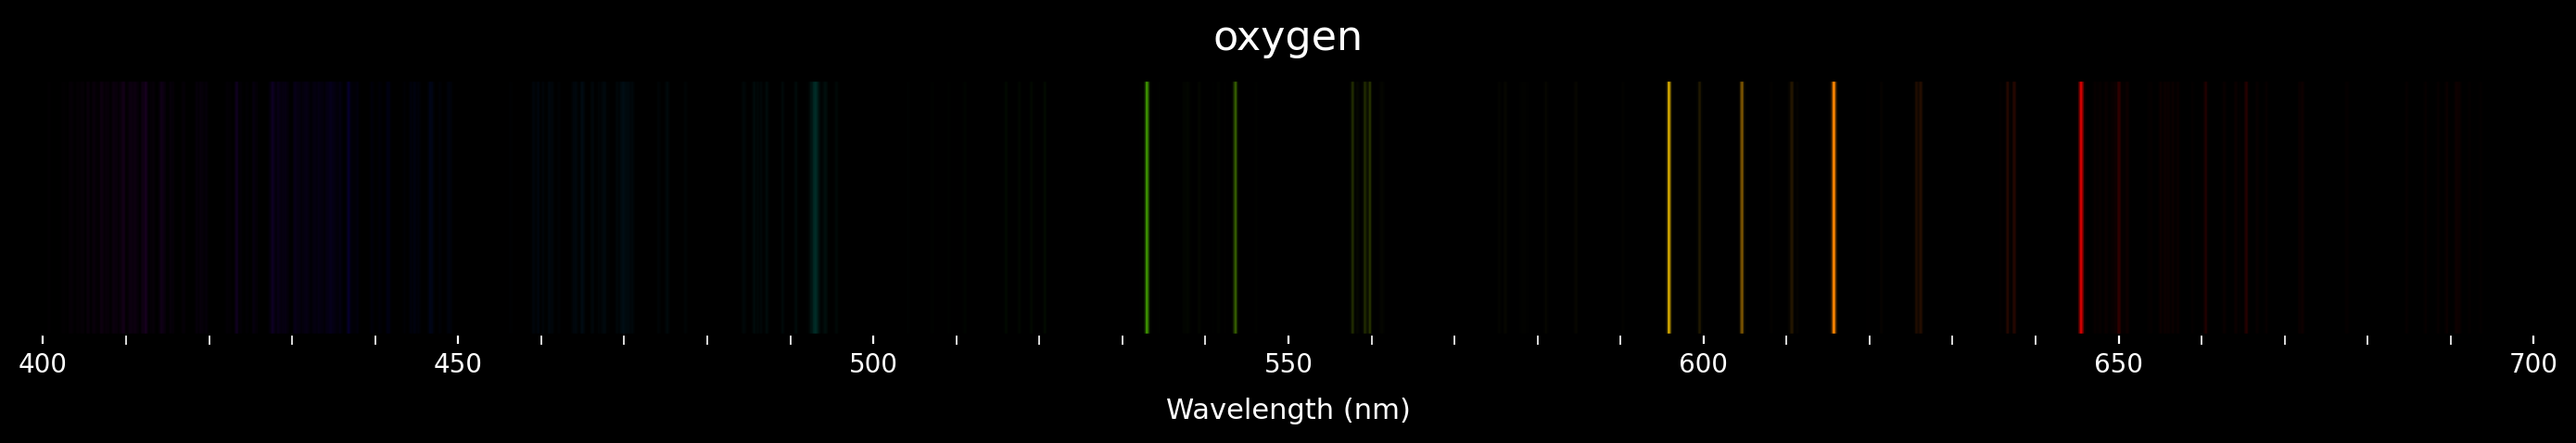

In [ ]:
# Convert intensity vs wavelength to a spectral image and display it.
# Uses existing np and plt from earlier cells.
def wavelength_to_rgb(wl, intensity=1.0):
    """Convert wavelength (nm) to RGB color with proper hue and intensity scaling."""
    wl = float(wl)
    r = g = b = 0.0

    # Wavelength to RGB conversion based on visible spectrum
    if 400 <= wl < 440:
        # Violet to Blue
        r = (440 - wl) / (440 - 400)
        b = 1.0
    elif 440 <= wl < 490:
        # Blue to Cyan
        g = (wl - 440) / (490 - 440)
        b = 1.0
    elif 490 <= wl < 510:
        # Cyan to Green
        g = 1.0
        b = (510 - wl) / (510 - 490)
    elif 510 <= wl < 580:
        # Green to Yellow
        r = (wl - 510) / (580 - 510)
        g = 1.0
    elif 580 <= wl < 645:
        # Yellow to Red
        r = 1.0
        g = (645 - wl) / (645 - 580)
    elif 645 <= wl <= 700:
        # Red
        r = 1.0
    else:
        return (0.0, 0.0, 0.0)

    # Eye sensitivity / visibility factor near edges
    if 400 <= wl < 420:
        factor = 0.3 + 0.7 * (wl - 400) / (420 - 400)
    elif 420 <= wl <= 700:
        factor = 1.0
    else:
        factor = 0.0

    # Apply intensity and gamma correction
    gamma = 0.8
    r = max(0.0, r * factor * intensity) ** gamma
    g = max(0.0, g * factor * intensity) ** gamma
    b = max(0.0, b * factor * intensity) ** gamma
    return (r, g, b)

# Create a high-resolution wavelength axis for descriptor-driven features
spectrum_range = np.linspace(400, 700, 4096)
core_intensity = np.zeros_like(spectrum_range)
glow_intensity = np.zeros_like(spectrum_range)

# Aggressively tighten non-line classes so broad descriptors are visible but not over-fat
action_sigma_factor = {
    'line': 1.0,
    'broad': 1.20,
    'cluster': 1.25,
    'blend': 0.70,
    'band-edge': 1.30,
    'doublet': 0.95,
}
base_sigma_nm = 0.12

glow_action_factor = {
    'line': 1.30,
    'broad': 1.45,
    'cluster': 1.40,
    'blend': 1.10,
    'band-edge': 1.50,
    'doublet': 1.25,
}
action_intensity_factor = {
    'line': 1.00,
    'broad': 0.50,
    'cluster': 0.80,
    'blend': 0.95,
    'band-edge': 0.70,
    'doublet': 1.00,
}
glow_strength = 0.14

def component_model(action):
    """Return (offsets_nm, weights) for descriptor action."""
    if action == 'doublet':
        return np.array([-0.11, 0.11]), np.array([0.5, 0.5])
    if action == 'cluster':
        return np.array([-0.09, 0.0, 0.09]), np.array([0.30, 0.40, 0.30])
    if action == 'blend':
        return np.array([-0.010, 0.010]), np.array([0.55, 0.45])
    if action == 'band-edge':
        return np.array([0.0, 0.08, 0.16]), np.array([0.60, 0.28, 0.12])
    return np.array([0.0]), np.array([1.0])

# Build spectrum with sharp core + restrained glow halo
for wl, inten, width_factor, action in zip(wavelengths, intensities, line_width_factors, line_actions):
    primary_action = action.split('+')[0] if action else 'line'
    core_sigma = max(0.025, base_sigma_nm * width_factor * action_sigma_factor.get(primary_action, 1.0))
    glow_sigma = core_sigma * glow_action_factor.get(primary_action, 1.30)
    scaled_intensity = inten * action_intensity_factor.get(primary_action, 1.0)

    offsets, weights = component_model(primary_action)
    for offset, weight in zip(offsets, weights):
        center = wl + offset
        core_profile = np.exp(-0.5 * ((spectrum_range - center) / core_sigma) ** 2)
        glow_profile = np.exp(-0.5 * ((spectrum_range - center) / glow_sigma) ** 2)
        core_intensity += scaled_intensity * weight * core_profile
        glow_intensity += scaled_intensity * weight * glow_profile

spectrum_intensity = core_intensity + glow_strength * glow_intensity

# Normalize to [0,1]
if spectrum_intensity.max() > 0:
    spectrum_intensity /= spectrum_intensity.max()

# Build RGB row from continuous spectrum
rgb_row = np.array([wavelength_to_rgb(wl, inten) for wl, inten in zip(spectrum_range, spectrum_intensity)])

# Convert centers to edges so we can draw a vector-style strip
spectrum_edges = np.empty(len(spectrum_range) + 1)
spectrum_edges[1:-1] = (spectrum_range[:-1] + spectrum_range[1:]) / 2
spectrum_edges[0] = spectrum_range[0] - (spectrum_range[1] - spectrum_range[0]) / 2
spectrum_edges[-1] = spectrum_range[-1] + (spectrum_range[-1] - spectrum_range[-2]) / 2

# Display with detailed x-axis labels and black background
fig, ax = plt.subplots(figsize=(14, 2.5), dpi=200, facecolor='black')
ax.set_facecolor('black')
ax.pcolormesh(spectrum_edges, [0, 1], rgb_row[np.newaxis, :, :], shading='flat')
ax.set_title(spectrum_title, color='white', fontsize=16, pad=12, loc='center')
ax.set_xlabel('Wavelength (nm)', fontsize=11, color='white')
ax.xaxis.set_label_coords(0.5, -0.25)
ax.set_ylabel('')
ax.set_yticks([])
ax.tick_params(colors='white')

# Major ticks every 50 nm; minor ticks every 10 nm
from matplotlib.ticker import MultipleLocator
major_ticks = [400, 450, 500, 550, 600, 650, 700]
ax.set_xticks(major_ticks)
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.tick_params(which='minor', length=4, colors='white')

fig.subplots_adjust(bottom=0.32)
plt.tight_layout()
plt.show()

## Convert to RBG Spectrum (Light Mode)

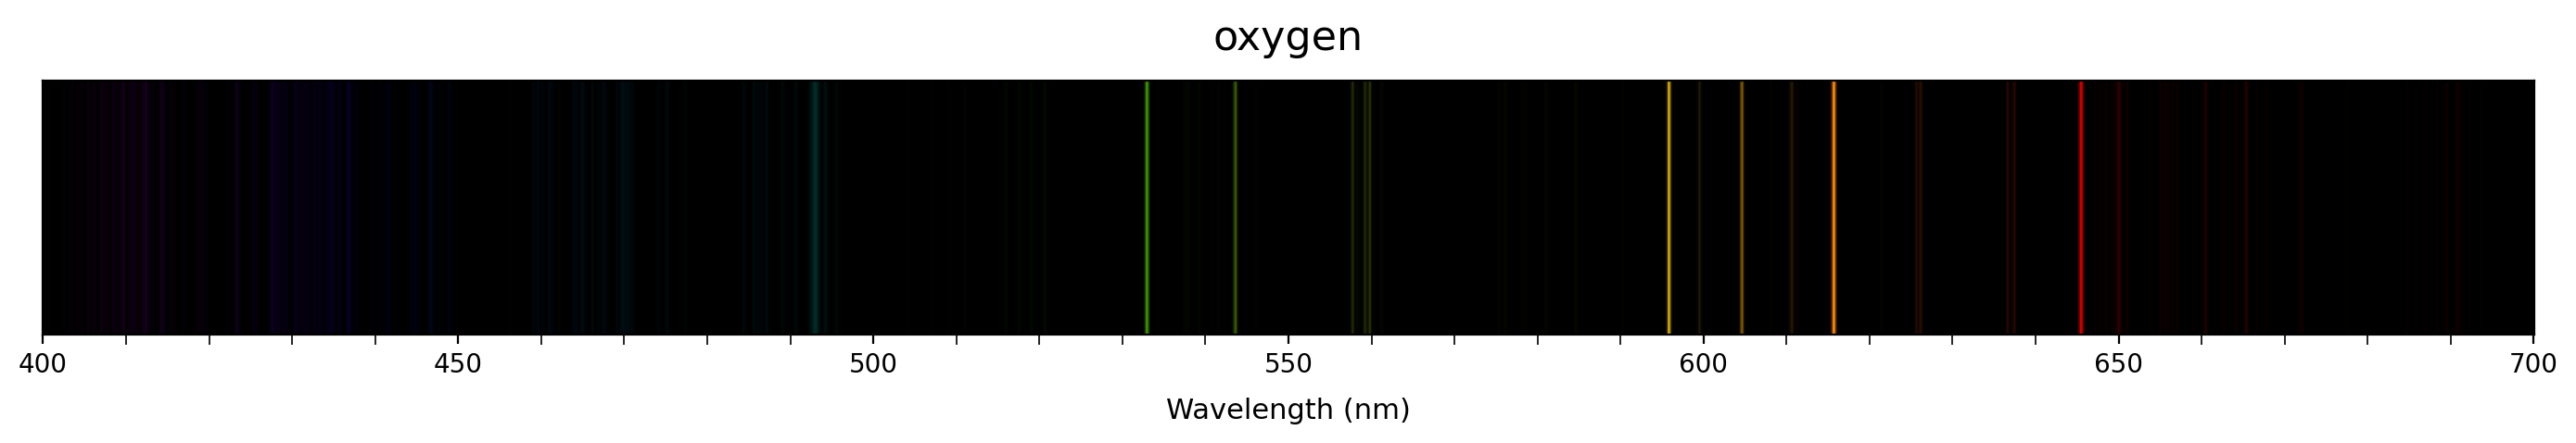

In [46]:
# Convert intensity vs wavelength to a spectral image and display it.
# Uses existing np and plt from earlier cells.
def wavelength_to_rgb(wl, intensity=1.0):
    """Convert wavelength (nm) to RGB color with proper hue and intensity scaling."""
    wl = float(wl)
    r = g = b = 0.0

    # Wavelength to RGB conversion based on visible spectrum
    if 400 <= wl < 440:
        # Violet to Blue
        r = (440 - wl) / (440 - 400)
        b = 1.0
    elif 440 <= wl < 490:
        # Blue to Cyan
        g = (wl - 440) / (490 - 440)
        b = 1.0
    elif 490 <= wl < 510:
        # Cyan to Green
        g = 1.0
        b = (510 - wl) / (510 - 490)
    elif 510 <= wl < 580:
        # Green to Yellow
        r = (wl - 510) / (580 - 510)
        g = 1.0
    elif 580 <= wl < 645:
        # Yellow to Red
        r = 1.0
        g = (645 - wl) / (645 - 580)
    elif 645 <= wl <= 700:
        # Red
        r = 1.0
    else:
        return (0.0, 0.0, 0.0)

    # Eye sensitivity / visibility factor near edges
    if 400 <= wl < 420:
        factor = 0.3 + 0.7 * (wl - 400) / (420 - 400)
    elif 420 <= wl <= 700:
        factor = 1.0
    else:
        factor = 0.0

    # Apply intensity and gamma correction
    gamma = 0.8
    r = max(0.0, r * factor * intensity) ** gamma
    g = max(0.0, g * factor * intensity) ** gamma
    b = max(0.0, b * factor * intensity) ** gamma
    return (r, g, b)

# Create a high-resolution wavelength axis for descriptor-driven features
spectrum_range = np.linspace(400, 700, 4096)
core_intensity = np.zeros_like(spectrum_range)
glow_intensity = np.zeros_like(spectrum_range)

# Aggressively tighten non-line classes so broad descriptors are visible but not over-fat
action_sigma_factor = {
    'line': 1.0,
    'broad': 1.20,
    'cluster': 1.25,
    'blend': 0.70,
    'band-edge': 1.30,
    'doublet': 0.95,
}
base_sigma_nm = 0.12

glow_action_factor = {
    'line': 1.30,
    'broad': 1.45,
    'cluster': 1.40,
    'blend': 1.10,
    'band-edge': 1.50,
    'doublet': 1.25,
}
action_intensity_factor = {
    'line': 1.00,
    'broad': 0.50,
    'cluster': 0.80,
    'blend': 0.95,
    'band-edge': 0.70,
    'doublet': 1.00,
}
glow_strength = 0.14

def component_model(action):
    """Return (offsets_nm, weights) for descriptor action."""
    if action == 'doublet':
        return np.array([-0.11, 0.11]), np.array([0.5, 0.5])
    if action == 'cluster':
        return np.array([-0.09, 0.0, 0.09]), np.array([0.30, 0.40, 0.30])
    if action == 'blend':
        return np.array([-0.010, 0.010]), np.array([0.55, 0.45])
    if action == 'band-edge':
        return np.array([0.0, 0.08, 0.16]), np.array([0.60, 0.28, 0.12])
    return np.array([0.0]), np.array([1.0])

# Build spectrum with sharp core + restrained glow halo
for wl, inten, width_factor, action in zip(wavelengths, intensities, line_width_factors, line_actions):
    primary_action = action.split('+')[0] if action else 'line'
    core_sigma = max(0.025, base_sigma_nm * width_factor * action_sigma_factor.get(primary_action, 1.0))
    glow_sigma = core_sigma * glow_action_factor.get(primary_action, 1.30)
    scaled_intensity = inten * action_intensity_factor.get(primary_action, 1.0)

    offsets, weights = component_model(primary_action)
    for offset, weight in zip(offsets, weights):
        center = wl + offset
        core_profile = np.exp(-0.5 * ((spectrum_range - center) / core_sigma) ** 2)
        glow_profile = np.exp(-0.5 * ((spectrum_range - center) / glow_sigma) ** 2)
        core_intensity += scaled_intensity * weight * core_profile
        glow_intensity += scaled_intensity * weight * glow_profile

spectrum_intensity = core_intensity + glow_strength * glow_intensity

# Normalize to [0,1]
if spectrum_intensity.max() > 0:
    spectrum_intensity /= spectrum_intensity.max()

# Build RGB row from continuous spectrum
rgb_row = np.array([wavelength_to_rgb(wl, inten) for wl, inten in zip(spectrum_range, spectrum_intensity)])

# Convert centers to edges so we can draw a vector-style strip
spectrum_edges = np.empty(len(spectrum_range) + 1)
spectrum_edges[1:-1] = (spectrum_range[:-1] + spectrum_range[1:]) / 2
spectrum_edges[0] = spectrum_range[0] - (spectrum_range[1] - spectrum_range[0]) / 2
spectrum_edges[-1] = spectrum_range[-1] + (spectrum_range[-1] - spectrum_range[-2]) / 2

# Display with detailed x-axis labels and white background
fig, ax = plt.subplots(figsize=(14, 2.5), dpi=200)
ax.pcolormesh(spectrum_edges, [0, 1], rgb_row[np.newaxis, :, :], shading='flat')
ax.set_title(spectrum_title, fontsize=16, pad=12, loc='center')
ax.set_xlabel('Wavelength (nm)', fontsize=11)
ax.xaxis.set_label_coords(0.5, -0.25)
ax.set_ylabel('')
ax.set_yticks([])

# Major ticks every 50 nm; minor ticks every 10 nm
from matplotlib.ticker import MultipleLocator
major_ticks = [400, 450, 500, 550, 600, 650, 700]
ax.set_xticks(major_ticks)
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.tick_params(which='minor', length=4)

fig.subplots_adjust(bottom=0.32)
plt.tight_layout()
plt.show()